# 2026-10-09 NSF BPT line ratios at fixed corrected Halpha surface brightness

**Question:** within the same corrected Halpha luminosity surface-density interval,
do NSF regions in pre-peak galaxies show higher BPT line ratios than those in
close-to-peak and post-peak galaxies? Here the **three catalogues are the three
stage samples**, each restricted to NSF. Stage is the proposed system-sSFR proxy;
this notebook does not measure or establish the global sSFR ordering.

For every common Sigma_Ha bin, one figure contains three panels: corrected
log10([O III]5007/Hbeta), log10([N II]6583/Halpha), and
log10(([S II]6716+[S II]6731)/Halpha). Each panel overlays pre-, close-to-,
and post-peak density-normalised histograms. All observables use all-region
`_FLUX_CORR` maps; `SII6716` and `SII6730` are the available doublet HDU names.

**Inherited selection:** inclination <80 deg, finite mass and gas-bin maps,
unmasked geometrically valid footprint, matching mass/gas WCS, and strict finite
`SNR_POSTFIT >25`. SF requires finite `LOGSFR_SURFACE_DENSITY_HII`, finite
proxy EW(Halpha)>6 Angstrom, and finite intrinsic Halpha dispersion <45 km/s.
NSF is the Balmer-detected usable-footprint complement of that SF selection,
then restricted by the postfit-S/N cut. NSF includes more than stable BPT
non-HII classes; no TNSF or extra EW selection is applied.

**Sigma_Ha:** $4\pi D^2 F_{\mathrm{H}\alpha,\mathrm{corr}}/A_{\mathrm{pixel}}$,
in erg s$^{-1}$ kpc$^{-2}$, with distance from `DIST_MPC` and projected pixel
area from the gas-map celestial WCS. No inclination correction. This controls
luminosity per projected physical area, not observed flux per pixel or SFR.
The default bins span the full finite NSF range in common 0.5-dex intervals.
Change `SIGMA_HA_BIN_WIDTH_DEX` or provide `SIGMA_HA_EDGES_DEX` below.

**Normalisation and limits:** every nonempty stage/ratio/bin histogram integrates
to one; shared full-range ratio edges avoid tail clipping. Only finite positive
fluxes enter a ratio (both SII components must qualify). No extra forbidden-line
detection cut is added. Ratios can therefore have different contributing pixels;
counts and exclusions are reported. These are pooled-spaxel descriptive PDFs,
with repeated gas-bin measurements and unequal galaxy footprints. Reported
median contrasts are not independent-pixel significance tests.

All input FITS files and source notebooks are read-only. Figures use `plt.show()`;
no plots or tables are automatically saved.

In [1]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy import units as u
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "v3tk_v7.6.8").is_dir():
    PROJECT_ROOT = Path("/Users/Igniz/Desktop/ICRAR/further")
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"
MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = ("{galid}_gas_bin_maps_further.fits", "{galid}_gas_BIN_maps_further.fits")
EW_FILE_PATTERNS = ("{galid}_proxy_EW_maps_further.fits", "{galid}_proxy_EW_maps.fits")
MASK_FILE_PATTERN = "{galid}_mask.fits"
SFH_FILE_PATTERN = "{galid}_sfh_maps.fits"
MASS_HDU, BIN_HDU_MASS, BIN_HDU_GAS = "LOGMASS_SURFACE_DENSITY", "BINID", "BIN_ID"
SFR_HDU, EW_HDU = "LOGSFR_SURFACE_DENSITY_HII", "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU, HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA", "HA6562_SIGMA_CORR"
MASK_TABLE_HDU, MASK_COLUMN = "MASKFILE", "MASK"
SFH_SNR_POSTFIT_HDU = "SNR_POSTFIT"
EW_HA_MIN, HALPHA_SIGMA_MAX, SFH_SNR_POSTFIT_MIN = 6.0, 45.0, 25.0
I_MAX_PRIMARY, WCS_TOLERANCE_ARCSEC = 80.0, 0.05
BALMER_LINES = ("HB4861", "HA6562")

STAGE_COLORS = {"pre-peak": "#2166ac", "close-to-peak": "#1a9850", "post-peak": "#d73027"}
STAGE_STYLES = {"pre-peak": "-", "close-to-peak": "--", "post-peak": ":"}
RATIO_ORDER = ("O3", "N2", "S2")
RATIO_LABELS = {
    "O3": r"$\log_{10}([\mathrm{O\,III}]5007/\mathrm{H}\beta)_{\mathrm{corr}}$",
    "N2": r"$\log_{10}([\mathrm{N\,II}]6583/\mathrm{H}\alpha)_{\mathrm{corr}}$",
    "S2": r"$\log_{10}(([\mathrm{S\,II}]6716+6731)/\mathrm{H}\alpha)_{\mathrm{corr}}$",
}
SIGMA_HA_BIN_WIDTH_DEX = 0.5
SIGMA_HA_EDGES_DEX = None  # e.g. np.arange(37.0, 41.5, 0.5); report excluded tails
N_RATIO_HIST_BINS = 50
MIN_GALAXIES_FOR_SUPPORT = 3  # flag only; does not remove any histogram
mpl.rcParams.update({"figure.dpi": 120, "font.size": 11})

SOURCE_NOTEBOOK = '20261007_check_corrected_Halpha_surface_density_BPT_PDFs_by_stage.ipynb'
SOURCE_NOTEBOOK_SHA256 = 'c7fe6db6cc2d1b3497221949ffbddee51c8be3340e89ce931c1337a39646109c'
print("Selection source:", SOURCE_NOTEBOOK, SOURCE_NOTEBOOK_SHA256)

Selection source: 20261007_check_corrected_Halpha_surface_density_BPT_PDFs_by_stage.ipynb c7fe6db6cc2d1b3497221949ffbddee51c8be3340e89ce931c1337a39646109c


## Inherited geometry, footprint and Balmer-only NSF definition

In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]

def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None

def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data

def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)

def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)

def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247

def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius

def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result

def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    snr_postfit = load_fits_map(row.sfh_path, SFH_SNR_POSTFIT_HDU)
    shapes = {a.shape for a in (
        mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr, snr_postfit
    )}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "snr_postfit": snr_postfit,
        "sigma_intrinsic": sigma_intrinsic,
        "gas_bin_id": gas_bin,
        "ew_ha": ew_ha,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf

    assert np.array_equal(sf.astype(np.int8) + nd + nsf, valid.astype(np.int8))
    maps.update({"nd_mask": nd, "nsf_mask": nsf,
                 "balmer_detected_mask": balmer_detected,
                 "detection_provenance": provenance})
    return maps

In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir()
                         if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": first_existing([folder / MASS_FILE_PATTERN.format(galid=galid)]),
            "sfr_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS
            ]),
            "ew_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS
            ]),
            "mask_path": first_existing([folder / MASK_FILE_PATTERN.format(galid=galid)]),
            "sfh_path": first_existing([
                folder / SFH_FILE_PATTERN.format(galid=galid)
            ]),
        })
    return pd.DataFrame(rows)


STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
STAGE_LABELS = {
    "pre-peak": "Pre-peak",
    "close-to-peak": "Close-to-peak",
    "post-peak": "Post-peak",
    "all stages": "All stages",
}

master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg",
    "center_dec_deg", "inclination_deg", "pa_deg_east_of_north",
    "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left",
    validate="one_to_one",
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
candidates = inventory.loc[
    inventory.stage.isin(STAGE_ORDER) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values(["stage", "GALID"]).reset_index(drop=True)

## Load paired Sigma_Ha and BPT measurements

Keep one row per selected NSF pixel, preserving its galaxy, gas-bin ID,
Sigma_Ha and all three ratios. The Halpha conditioning and each ratio selection
are applied to the **same pixel**, not separately sorted or concatenated arrays.
Missing products and failed map checks appear in `SAMPLE_QC`.

In [4]:
def positive_log10(values):
    result = np.full(values.shape, np.nan, dtype=float)
    good = np.isfinite(values) & (values > 0)
    result[good] = np.log10(values[good])
    return result

def corrected_measurements(row, shape):
    lines = ("HA6562", "HB4861", "OIII5006", "NII6583", "SII6716", "SII6730")
    with fits.open(row.sfr_path, memmap=True) as hdul:
        flux = {}
        for line in lines:
            hdu = hdul[line + "_FLUX_CORR"]
            if hdu.data.shape != shape:
                raise ValueError(f"{row.GALID}: {line} corrected map shape mismatch")
            if hdu.header.get("BUNIT", "").strip() != "1e-20 erg s-1 cm-2":
                raise ValueError(f"{row.GALID}: {line} unexpected corrected flux unit")
            flux[line] = np.asarray(hdu.data, dtype=float).copy()
        distance = float(hdul[0].header["DIST_MPC"])
        wcs = WCS(hdul[BIN_HDU_GAS].header).celestial
        if not wcs.has_celestial:
            raise ValueError(f"{row.GALID}: no gas-map celestial WCS")
        scales = proj_plane_pixel_scales(wcs)
        if (scales.size != 2 or not np.all(np.isfinite(scales) & (scales > 0))
                or not (np.isfinite(distance) and distance > 0)):
            raise ValueError(f"{row.GALID}: invalid distance/pixel scales")
        area_kpc2 = float(np.prod(np.deg2rad(scales) * distance * 1000))
        luminosity_factor = 1e-20 * 4 * np.pi * (distance * u.Mpc).to_value(u.cm)**2
        direct_lum = flux["HA6562"] * luminosity_factor
        stored_lum = np.asarray(hdul["HALPHA_LUMINOSITY_CORR"].data, dtype=float).copy()
        if stored_lum.shape != shape:
            raise ValueError(f"{row.GALID}: stored Halpha luminosity shape mismatch")
    variables = {"log_Sigma_Ha": positive_log10(direct_lum / area_kpc2)}
    for key, numerator_lines, denominator in (
        ("O3", ("OIII5006",), "HB4861"),
        ("N2", ("NII6583",), "HA6562"),
        ("S2", ("SII6716", "SII6730"), "HA6562"),
    ):
        good = np.isfinite(flux[denominator]) & (flux[denominator] > 0)
        numerator = np.zeros(shape, dtype=float)
        for line in numerator_lines:
            good &= np.isfinite(flux[line]) & (flux[line] > 0)
            numerator += flux[line]
        ratio = np.full(shape, np.nan)
        with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
            ratio[good] = numerator[good] / flux[denominator][good]
        variables[key] = positive_log10(ratio)
    return variables, stored_lum, direct_lum, {"DIST_MPC": distance, "pixel_area_kpc2": area_kpc2}

frames, qc_rows, provenance_rows = [], [], []
for row in candidates.itertuples(index=False):
    flags = []
    n_nsf = n_sigma = 0
    for label in ("mass", "sfr", "ew", "mask", "sfh"):
        path = getattr(row, label + "_path")
        if not isinstance(path, Path) or not path.exists():
            flags.append("missing_" + label + "_product")
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            keep = (maps["valid_disc_mask"] & np.isfinite(maps["snr_postfit"])
                    & (maps["snr_postfit"] > SFH_SNR_POSTFIT_MIN))
            nsf = maps["nsf_mask"] & keep
            assert not np.any(nsf & maps["sf_mask"])
            assert np.all(maps["balmer_detected_mask"][nsf])
            variables, stored_lum, direct_lum, provenance = corrected_measurements(row, nsf.shape)
            detected = keep & maps["balmer_detected_mask"] & np.isfinite(direct_lum) & (direct_lum > 0)
            if not detected.any() or not np.allclose(stored_lum[detected], direct_lum[detected], rtol=1e-6, atol=0):
                raise ValueError("stored/direct corrected Halpha luminosity disagreement")
            n_nsf = int(nsf.sum())
            selected = nsf & np.isfinite(variables["log_Sigma_Ha"])
            n_sigma = int(selected.sum())
            pixel_y, pixel_x = np.nonzero(selected)
            frame = pd.DataFrame({"GALID": row.GALID, "stage": row.stage,
                "pixel_y": pixel_y, "pixel_x": pixel_x,
                "gas_bin_id": maps["gas_bin_id"][selected],
                **{name: values[selected] for name, values in variables.items()}})
            provenance_rows.append({"GALID": row.GALID, "stage": row.stage,
                **maps["detection_provenance"], **provenance,
                "mass_gas_WCS_offset_arcsec": maps["wcs_separation_arcsec"],
                "gas_path": str(row.sfr_path)})
            frames.append(frame)
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    qc_rows.append({"GALID": row.GALID, "components": row.components, "stage": row.stage,
        "inclination_deg": row.inclination, "N_NSF": n_nsf, "N_finite_Sigma_Ha": n_sigma,
        "QC_flag": ";".join(flags) if flags else "OK"})

SAMPLE_QC = pd.DataFrame(qc_rows)
PROVENANCE = pd.DataFrame(provenance_rows)
display(SAMPLE_QC)
display(PROVENANCE)
if not frames:
    raise RuntimeError("No NSF products pass QC")
NSF_PIXELS = pd.concat(frames, ignore_index=True)
assert not NSF_PIXELS.duplicated(["GALID", "pixel_y", "pixel_x"]).any()
assert np.isfinite(NSF_PIXELS.log_Sigma_Ha).all()
for stage in STAGE_ORDER:
    ids = SAMPLE_QC.loc[SAMPLE_QC.stage.eq(stage) & SAMPLE_QC.QC_flag.eq("OK"), "GALID"].tolist()
    print(f"{STAGE_LABELS[stage]}: {len(ids)} passing products: {', '.join(ids)}")
    if not NSF_PIXELS.stage.eq(stage).any():
        raise RuntimeError(f"No finite NSF Sigma_Ha pixels in {stage}")

Pre-peak: 8 passing products: NGC4189, NGC4254, NGC4294, NGC4321, NGC4351, NGC4383, NGC4535, NGC4567_8
Close-to-peak: 5 passing products: NGC4298, NGC4424, NGC4501, NGC4654, NGC4694
Post-peak: 13 passing products: IC3392, NGC4064, NGC4293, NGC4380, NGC4394, NGC4405, NGC4419, NGC4450, NGC4457, NGC4569, NGC4580, NGC4606, NGC4698


,GALID,components,stage,inclination_deg,N_NSF,N_finite_Sigma_Ha,QC_flag
0,NGC4298,NGC4298,close-to-peak,52.0,43104,43104,OK
1,NGC4424,NGC4424,close-to-peak,61.0,37811,37811,OK
2,NGC4501,NGC4501,close-to-peak,65.0,261968,261968,OK
3,NGC4654,NGC4654,close-to-peak,61.0,117845,117845,OK
4,NGC4694,NGC4694,close-to-peak,62.0,28137,28137,OK
5,IC3392,IC3392,post-peak,68.0,9123,9123,OK
6,NGC4064,NGC4064,post-peak,70.0,33921,33921,OK
7,NGC4293,NGC4293,post-peak,67.0,63400,63400,OK
8,NGC4380,NGC4380,post-peak,61.0,51190,51190,OK
9,NGC4394,NGC4394,post-peak,32.0,45294,45294,OK


,GALID,stage,CUT_SN,NOISE,BPTMODE,BPTLIMIT,DUSTLAW,DIST_MPC,pixel_area_kpc2,mass_gas_WCS_offset_arcsec,gas_path
0,NGC4298,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256,0.0,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
1,NGC4424,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256,0.0,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
2,NGC4501,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256,0.0,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
3,NGC4654,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256,0.0,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
4,NGC4694,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256,0.0,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
5,IC3392,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256,0.0,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
6,NGC4064,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256,0.0,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
7,NGC4293,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256,0.0,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
8,NGC4380,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256,0.0,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
9,NGC4394,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256,0.0,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...


## Common Halpha intervals and common ratio edges

Intervals are `[low, high)`, with the final upper edge included. User-supplied
edges can restrict the range; excluded pixels are counted explicitly.
`BIN_SUPPORT` also reports median Sigma_Ha per stage: unequal distributions
within a finite-width interval leave residual Halpha differences. Thinly
populated bins remain visible and are flagged rather than silently removed.

In [5]:
def assign_sigma_bins(values, edges):
    values, edges = np.asarray(values, float), np.asarray(edges, float)
    if edges.ndim != 1 or len(edges) < 2 or not np.isfinite(edges).all() or not np.all(np.diff(edges) > 0):
        raise ValueError("Sigma_Ha edges must be finite and strictly increasing")
    assigned = np.searchsorted(edges, values, side="right") - 1
    assigned[values == edges[-1]] = len(edges) - 2
    outside = ~np.isfinite(values) | (values < edges[0]) | (values > edges[-1])
    assigned[outside] = -1
    return assigned

if SIGMA_HA_EDGES_DEX is None:
    if not np.isfinite(SIGMA_HA_BIN_WIDTH_DEX) or SIGMA_HA_BIN_WIDTH_DEX <= 0:
        raise ValueError("Sigma_Ha bin width must be positive and finite")
    width = SIGMA_HA_BIN_WIDTH_DEX
    lo = np.floor(NSF_PIXELS.log_Sigma_Ha.min() / width) * width
    nbin = max(1, int(np.ceil((NSF_PIXELS.log_Sigma_Ha.max() - lo) / width)))
    SIGMA_EDGES = lo + np.arange(nbin + 1) * width
    if SIGMA_EDGES[-1] < NSF_PIXELS.log_Sigma_Ha.max():
        SIGMA_EDGES = np.append(SIGMA_EDGES, SIGMA_EDGES[-1] + width)
else:
    SIGMA_EDGES = np.asarray(SIGMA_HA_EDGES_DEX, dtype=float)
NSF_PIXELS["Sigma_bin"] = assign_sigma_bins(NSF_PIXELS.log_Sigma_Ha, SIGMA_EDGES)
N_SIGMA_BINS = len(SIGMA_EDGES) - 1
display(NSF_PIXELS.assign(outside=NSF_PIXELS.Sigma_bin.lt(0)).groupby("stage")["outside"].agg(["sum", "count"]))
if SIGMA_HA_EDGES_DEX is None:
    assert NSF_PIXELS.Sigma_bin.ge(0).all()

RATIO_EDGES = {}
assert isinstance(N_RATIO_HIST_BINS, int) and N_RATIO_HIST_BINS > 0
for ratio in RATIO_ORDER:
    values = NSF_PIXELS.loc[NSF_PIXELS.Sigma_bin.ge(0), ratio].to_numpy()
    values = values[np.isfinite(values)]
    if not values.size:
        raise RuntimeError(f"No finite {ratio} values in the requested Sigma_Ha range")
    low, high = values.min(), values.max()
    if low == high:
        low, high = low - 0.5, high + 0.5
    RATIO_EDGES[ratio] = np.linspace(low, high, N_RATIO_HIST_BINS + 1)

support_rows = []
for b in range(N_SIGMA_BINS):
    for stage in STAGE_ORDER:
        parent = NSF_PIXELS.loc[NSF_PIXELS.Sigma_bin.eq(b) & NSF_PIXELS.stage.eq(stage)]
        for ratio in RATIO_ORDER:
            measured = parent.loc[np.isfinite(parent[ratio])]
            ng = measured.GALID.nunique()
            support_rows.append({"Sigma_bin": b, "low": SIGMA_EDGES[b], "high": SIGMA_EDGES[b+1],
                "stage": stage, "ratio": ratio, "N_parent": len(parent), "N_finite": len(measured),
                "N_unavailable": len(parent)-len(measured), "N_galaxies": ng,
                "N_gas_bins": len(measured[["GALID", "gas_bin_id"]].drop_duplicates()),
                "median_log_Sigma_Ha": measured.log_Sigma_Ha.median(),
                "median_log_ratio": measured[ratio].median(),
                "low_galaxy_support": ng < MIN_GALAXIES_FOR_SUPPORT})
BIN_SUPPORT = pd.DataFrame(support_rows)
display(BIN_SUPPORT)
print("Shared log10 Sigma_Ha edges [erg s-1 kpc-2]:", SIGMA_EDGES)

Shared log10 Sigma_Ha edges [erg s-1 kpc-2]: [37.  37.5 38.  38.5 39.  39.5 40.  40.5 41.  41.5 42.  42.5 43. ]


,sum,count
stage,,
close-to-peak,0,488865
post-peak,0,815887
pre-peak,0,929104


,Sigma_bin,low,high,stage,ratio,N_parent,N_finite,N_unavailable,N_galaxies,N_gas_bins,median_log_Sigma_Ha,median_log_ratio,low_galaxy_support
0,0,37.0,37.5,pre-peak,O3,0,0,0,0,0,NaN,NaN,True
1,0,37.0,37.5,pre-peak,N2,0,0,0,0,0,NaN,NaN,True
2,0,37.0,37.5,pre-peak,S2,0,0,0,0,0,NaN,NaN,True
3,0,37.0,37.5,close-to-peak,O3,367,235,132,3,9,37.448651,-0.623166,False
4,0,37.0,37.5,close-to-peak,N2,367,235,132,3,9,37.448651,-0.328545,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,11,42.5,43.0,close-to-peak,N2,0,0,0,0,0,NaN,NaN,True
104,11,42.5,43.0,close-to-peak,S2,0,0,0,0,0,NaN,NaN,True
105,11,42.5,43.0,post-peak,O3,22,22,0,2,22,42.631544,-0.026045,True
106,11,42.5,43.0,post-peak,N2,22,22,0,2,22,42.631544,-0.067802,True


## NSF ratio histograms: three stage catalogues in every Halpha bin

Each figure has O3, N2, S2 columns. Solid blue = pre-peak; dashed green =
close-to-peak; dotted red = post-peak. Vertical lines indicate pooled medians.
The legend reports finite pixel counts and contributing galaxy counts; an
asterisk marks fewer than `MIN_GALAXIES_FOR_SUPPORT` galaxies. Before each
figure, print the corresponding support table including median Sigma_Ha.

Sigma_Ha bin 0: log10 interval [37.00, 37.50)
Sigma_Ha bin 1: log10 interval [37.50, 38.00)
Sigma_Ha bin 2: log10 interval [38.00, 38.50)
Sigma_Ha bin 3: log10 interval [38.50, 39.00)
Sigma_Ha bin 4: log10 interval [39.00, 39.50)
Sigma_Ha bin 5: log10 interval [39.50, 40.00)
Sigma_Ha bin 6: log10 interval [40.00, 40.50)
Sigma_Ha bin 7: log10 interval [40.50, 41.00)
Sigma_Ha bin 8: log10 interval [41.00, 41.50)
Sigma_Ha bin 9: log10 interval [41.50, 42.00)
Sigma_Ha bin 10: log10 interval [42.00, 42.50)
Sigma_Ha bin 11: log10 interval [42.50, 43.00]


,Sigma_bin,low,high,stage,ratio,N_parent,N_finite,N_unavailable,N_galaxies,N_gas_bins,median_log_Sigma_Ha,median_log_ratio,low_galaxy_support
0,0,37.0,37.5,pre-peak,O3,0,0,0,0,0,NaN,NaN,True
1,0,37.0,37.5,pre-peak,N2,0,0,0,0,0,NaN,NaN,True
2,0,37.0,37.5,pre-peak,S2,0,0,0,0,0,NaN,NaN,True
3,0,37.0,37.5,close-to-peak,O3,367,235,132,3,9,37.448651,-0.623166,False
4,0,37.0,37.5,close-to-peak,N2,367,235,132,3,9,37.448651,-0.328545,False
5,0,37.0,37.5,close-to-peak,S2,367,262,105,3,10,37.438966,-0.413421,False
6,0,37.0,37.5,post-peak,O3,1499,1465,34,8,56,37.459919,-0.238887,False
7,0,37.0,37.5,post-peak,N2,1499,1464,35,8,56,37.462567,-0.044889,False
8,0,37.0,37.5,post-peak,S2,1499,1158,341,7,46,37.459919,-0.266038,False


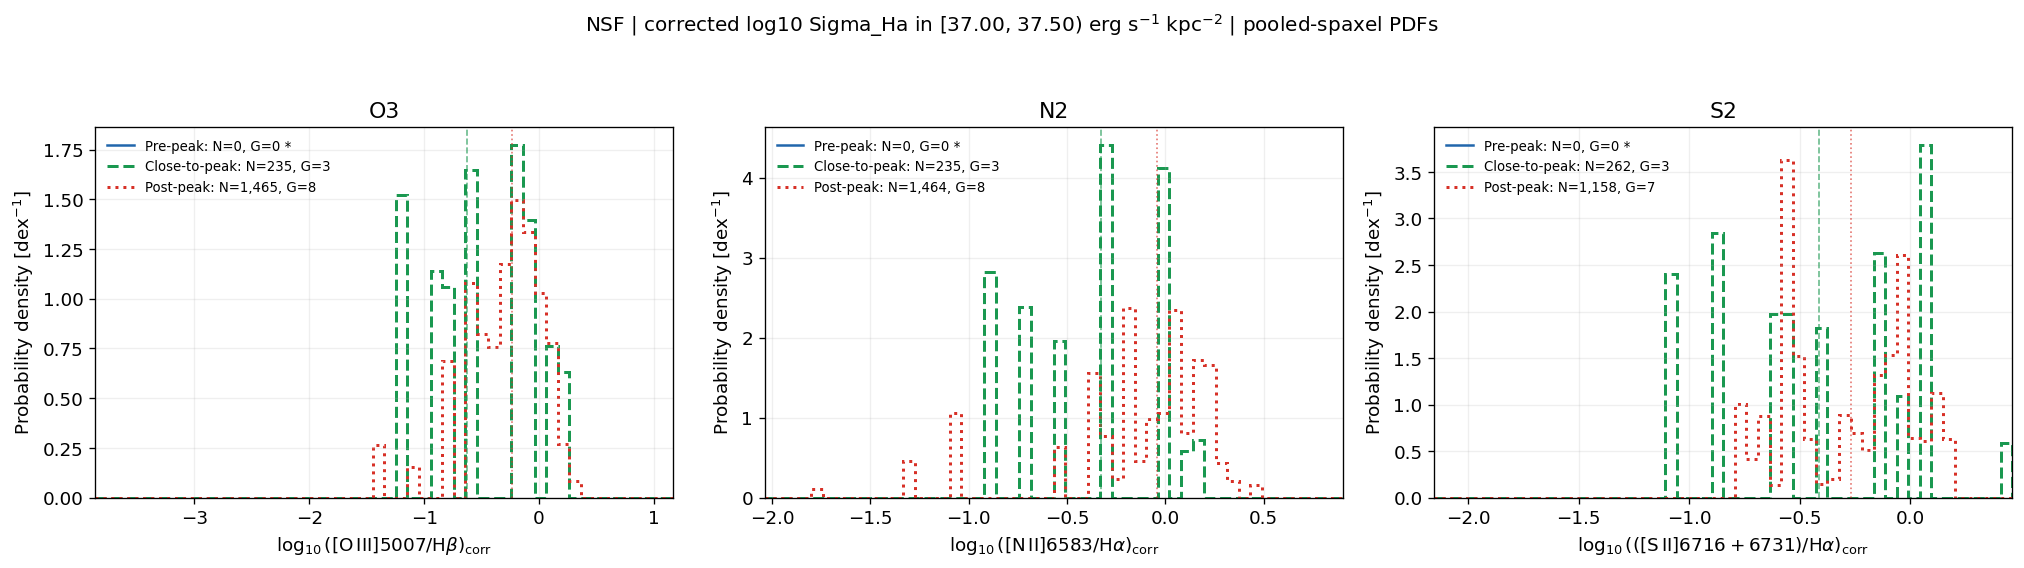

,Sigma_bin,low,high,stage,ratio,N_parent,N_finite,N_unavailable,N_galaxies,N_gas_bins,median_log_Sigma_Ha,median_log_ratio,low_galaxy_support
9,1,37.5,38.0,pre-peak,O3,45996,45595,401,8,1331,37.905462,-0.193471,False
10,1,37.5,38.0,pre-peak,N2,45996,45996,0,8,1338,37.906116,-0.098692,False
11,1,37.5,38.0,pre-peak,S2,45996,45996,0,8,1338,37.906116,-0.173299,False
12,1,37.5,38.0,close-to-peak,O3,26761,26443,318,5,734,37.897582,-0.160813,False
13,1,37.5,38.0,close-to-peak,N2,26761,26631,130,5,745,37.897247,-0.194547,False
14,1,37.5,38.0,close-to-peak,S2,26761,26409,352,5,738,37.897582,-0.089633,False
15,1,37.5,38.0,post-peak,O3,151495,150748,747,13,9242,37.867392,0.049786,False
16,1,37.5,38.0,post-peak,N2,151495,151190,305,13,9269,37.867354,0.012211,False
17,1,37.5,38.0,post-peak,S2,151495,147513,3982,13,9094,37.869878,-0.148520,False


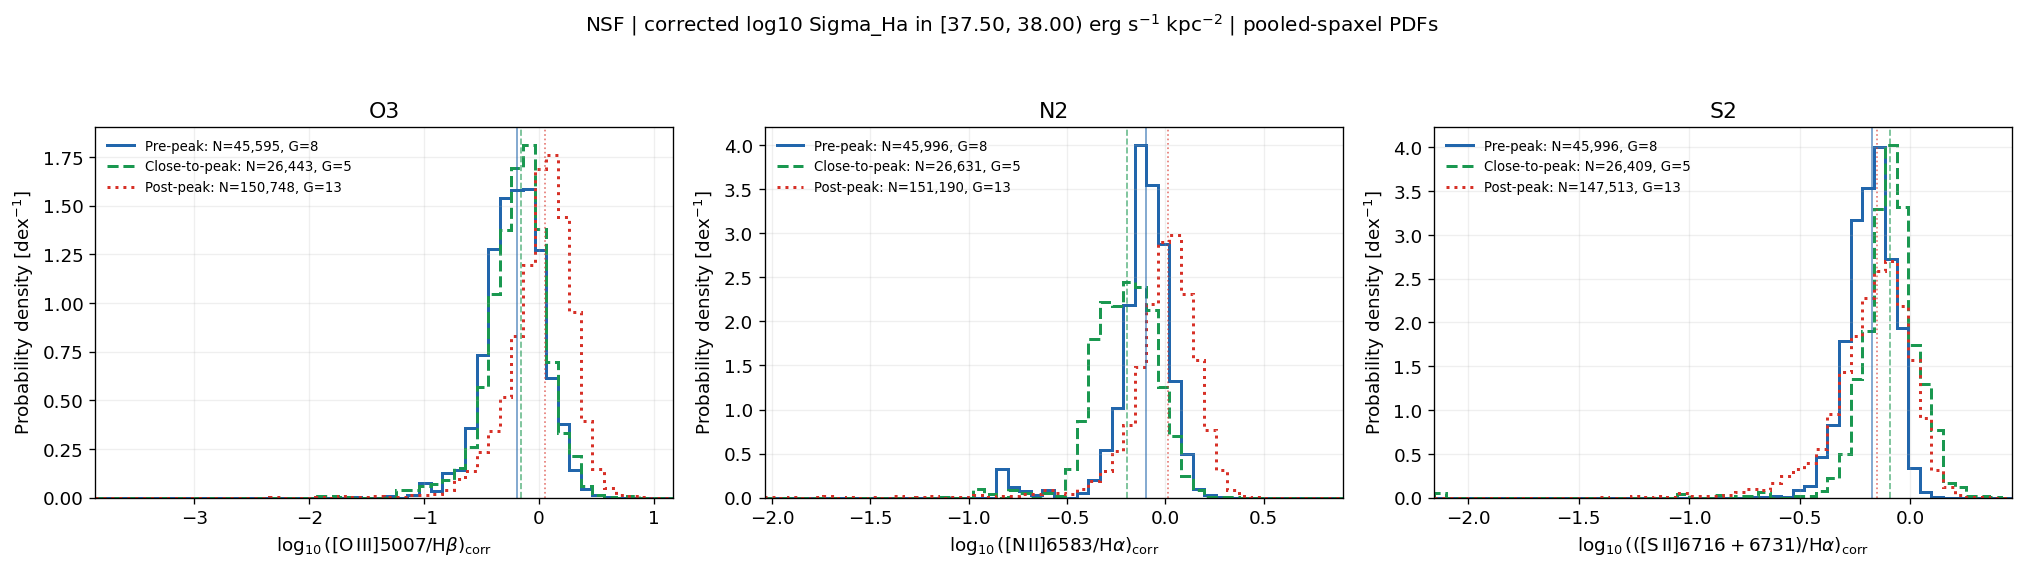

,Sigma_bin,low,high,stage,ratio,N_parent,N_finite,N_unavailable,N_galaxies,N_gas_bins,median_log_Sigma_Ha,median_log_ratio,low_galaxy_support
18,2,38.0,38.5,pre-peak,O3,297544,295601,1943,8,8616,38.310043,-0.248797,False
19,2,38.0,38.5,pre-peak,N2,297544,297544,0,8,8665,38.310161,-0.210588,False
20,2,38.0,38.5,pre-peak,S2,297544,297531,13,8,8664,38.310161,-0.226455,False
21,2,38.0,38.5,close-to-peak,O3,135583,135347,236,5,4602,38.302180,-0.178756,False
22,2,38.0,38.5,close-to-peak,N2,135583,135583,0,5,4614,38.302563,-0.265817,False
23,2,38.0,38.5,close-to-peak,S2,135583,135526,57,5,4606,38.302691,-0.148523,False
24,2,38.0,38.5,post-peak,O3,286499,285594,905,13,27879,38.248684,0.084666,False
25,2,38.0,38.5,post-peak,N2,286499,286441,58,13,27923,38.248792,-0.036080,False
26,2,38.0,38.5,post-peak,S2,286499,285760,739,13,27837,38.249244,-0.148833,False


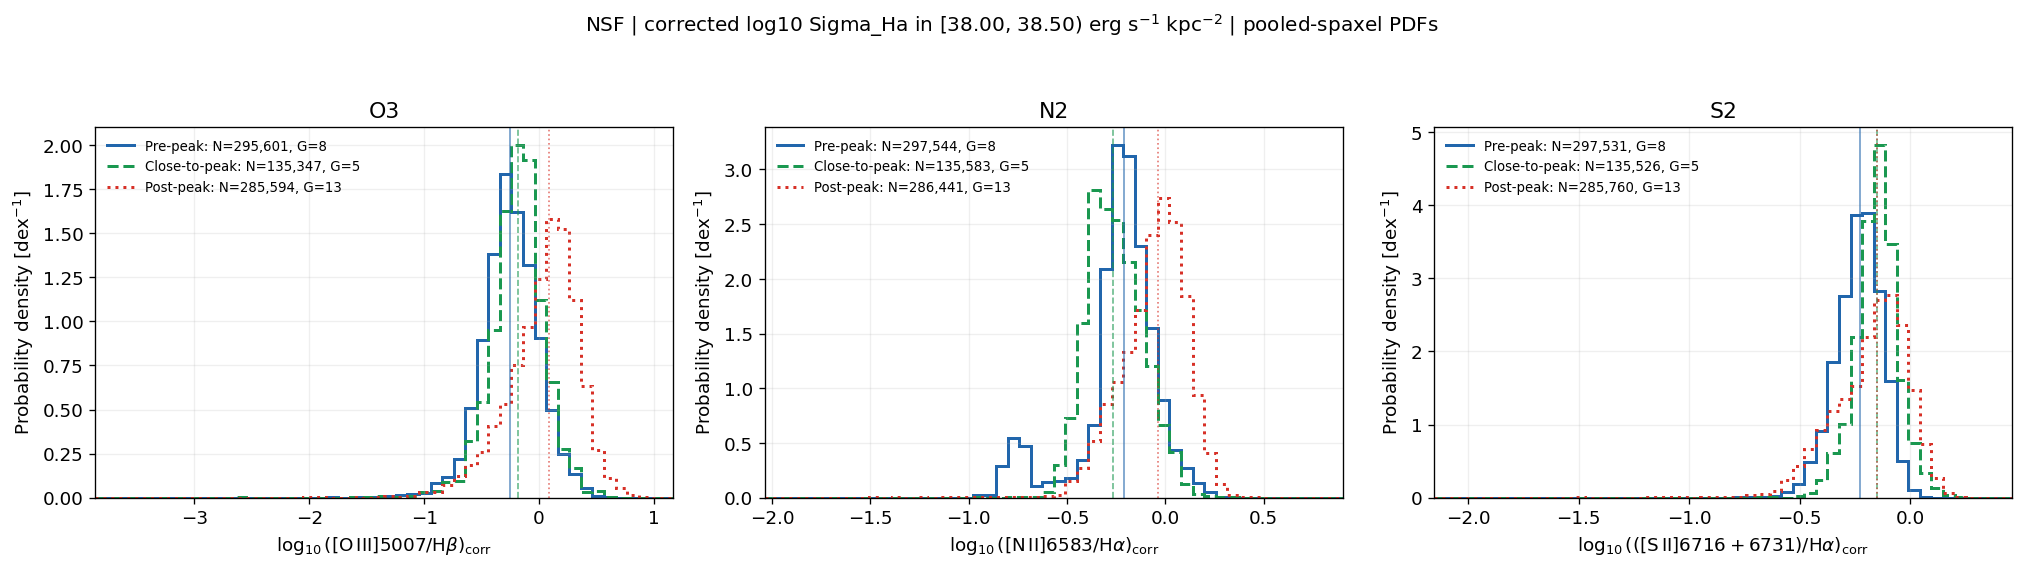

,Sigma_bin,low,high,stage,ratio,N_parent,N_finite,N_unavailable,N_galaxies,N_gas_bins,median_log_Sigma_Ha,median_log_ratio,low_galaxy_support
27,3,38.5,39.0,pre-peak,O3,382175,379619,2556,8,16465,38.724212,-0.240240,False
28,3,38.5,39.0,pre-peak,N2,382175,382175,0,8,16543,38.724002,-0.245587,False
29,3,38.5,39.0,pre-peak,S2,382175,382175,0,8,16543,38.724002,-0.296614,False
30,3,38.5,39.0,close-to-peak,O3,172471,172035,436,5,12316,38.733490,-0.206731,False
31,3,38.5,39.0,close-to-peak,N2,172471,172471,0,5,12405,38.733612,-0.252894,False
32,3,38.5,39.0,close-to-peak,S2,172471,172468,3,5,12403,38.733612,-0.225783,False
33,3,38.5,39.0,post-peak,O3,209399,208421,978,13,33492,38.708999,0.030629,False
34,3,38.5,39.0,post-peak,N2,209399,209399,0,13,33619,38.709189,-0.086812,False
35,3,38.5,39.0,post-peak,S2,209399,209334,65,13,33575,38.709191,-0.207137,False


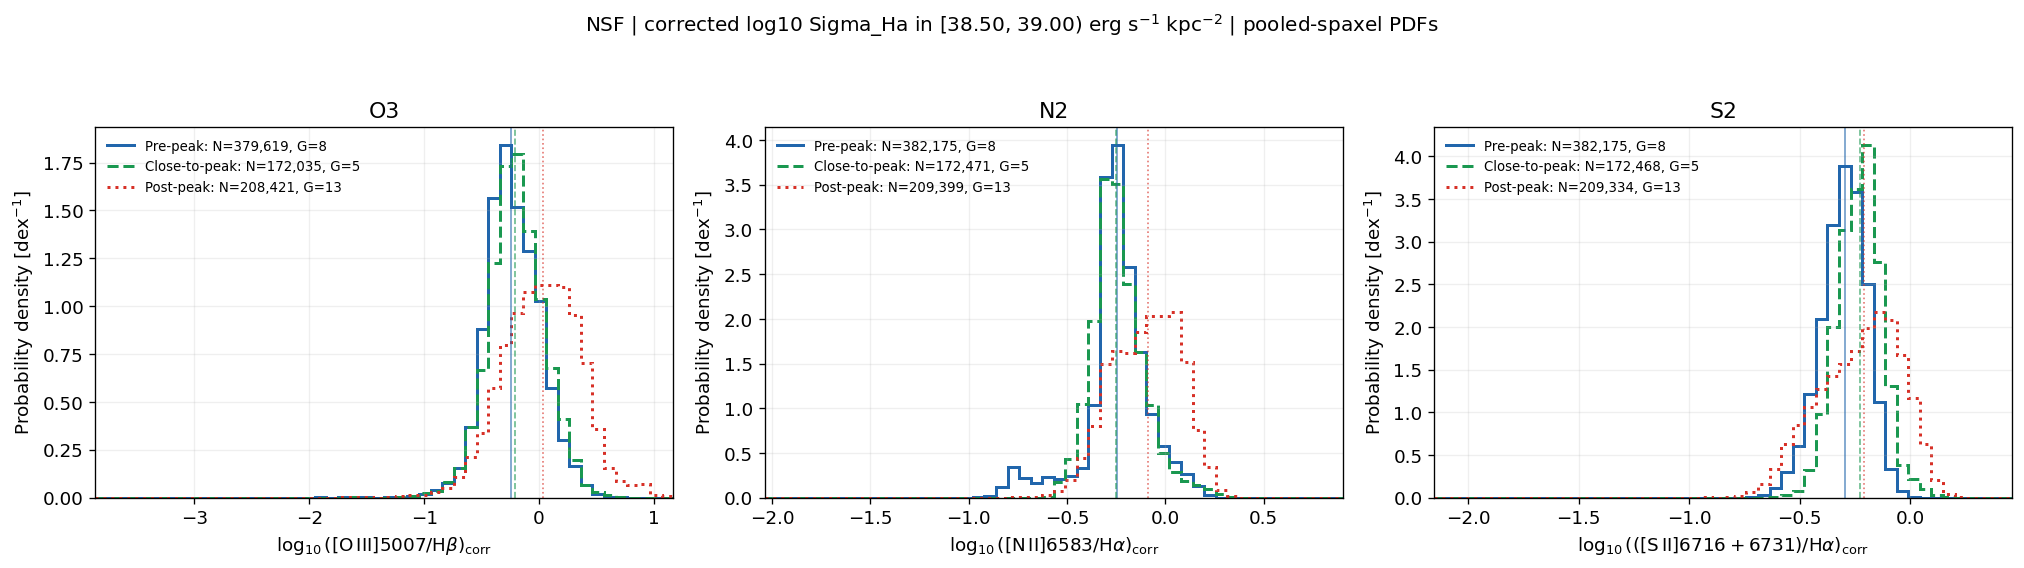

,Sigma_bin,low,high,stage,ratio,N_parent,N_finite,N_unavailable,N_galaxies,N_gas_bins,median_log_Sigma_Ha,median_log_ratio,low_galaxy_support
36,4,39.0,39.5,pre-peak,O3,152482,151855,627,8,11991,39.176059,-0.203653,False
37,4,39.0,39.5,pre-peak,N2,152482,152482,0,8,12015,39.176022,-0.263001,False
38,4,39.0,39.5,pre-peak,S2,152482,152482,0,8,12015,39.176022,-0.362073,False
39,4,39.0,39.5,close-to-peak,O3,107193,106739,454,5,20513,39.216694,-0.201971,False
40,4,39.0,39.5,close-to-peak,N2,107193,107193,0,5,20664,39.216918,-0.235672,False
41,4,39.0,39.5,close-to-peak,S2,107193,107190,3,5,20662,39.216918,-0.329593,False
42,4,39.0,39.5,post-peak,O3,109900,109086,814,13,30130,39.209851,-0.029439,False
43,4,39.0,39.5,post-peak,N2,109900,109900,0,13,30415,39.210200,-0.141581,False
44,4,39.0,39.5,post-peak,S2,109900,109883,17,13,30400,39.210218,-0.280819,False


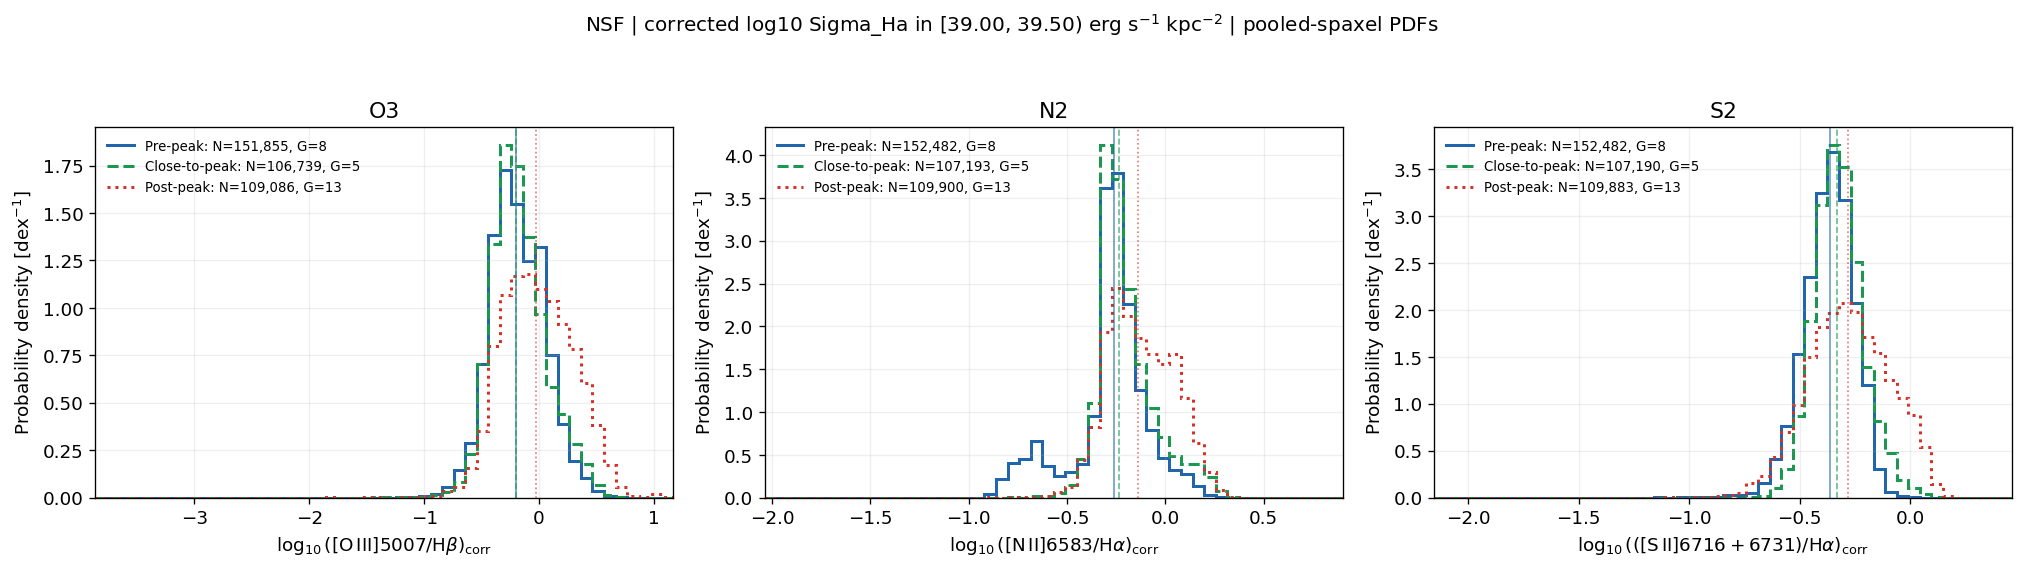

,Sigma_bin,low,high,stage,ratio,N_parent,N_finite,N_unavailable,N_galaxies,N_gas_bins,median_log_Sigma_Ha,median_log_ratio,low_galaxy_support
45,5,39.5,40.0,pre-peak,O3,35406,35301,105,8,6190,39.667639,-0.247955,False
46,5,39.5,40.0,pre-peak,N2,35406,35406,0,8,6200,39.667580,-0.304945,False
47,5,39.5,40.0,pre-peak,S2,35406,35406,0,8,6200,39.667580,-0.448706,False
48,5,39.5,40.0,close-to-peak,O3,40909,40578,331,5,13767,39.658322,-0.185156,False
49,5,39.5,40.0,close-to-peak,N2,40909,40909,0,5,13899,39.658832,-0.232598,False
50,5,39.5,40.0,close-to-peak,S2,40909,40909,0,5,13899,39.658832,-0.418398,False
51,5,39.5,40.0,post-peak,O3,42478,41803,675,13,18266,39.676965,0.003006,False
52,5,39.5,40.0,post-peak,N2,42478,42478,0,13,18508,39.677159,-0.156791,False
53,5,39.5,40.0,post-peak,S2,42478,42478,0,13,18508,39.677159,-0.320317,False


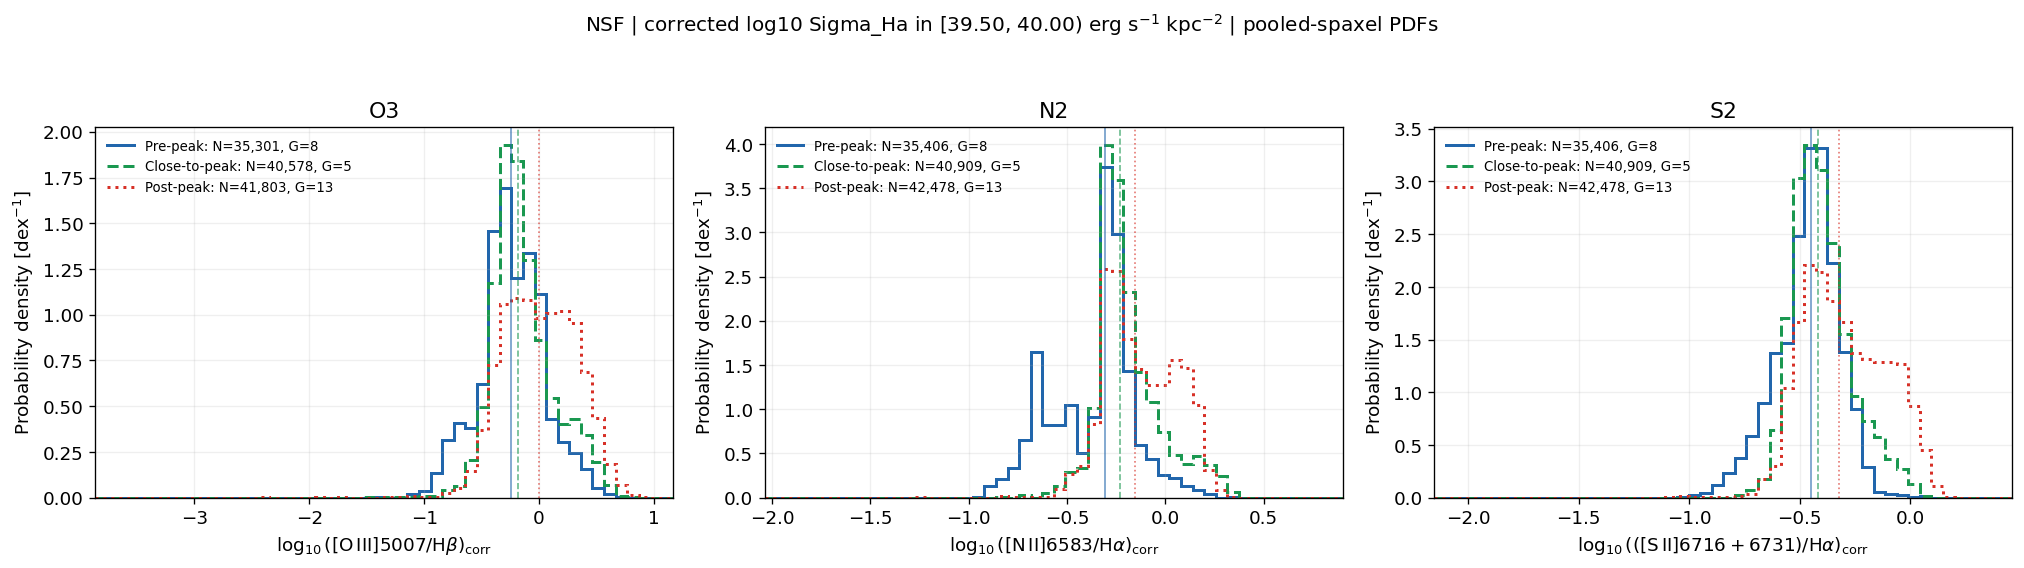

,Sigma_bin,low,high,stage,ratio,N_parent,N_finite,N_unavailable,N_galaxies,N_gas_bins,median_log_Sigma_Ha,median_log_ratio,low_galaxy_support
54,6,40.0,40.5,pre-peak,O3,9263,9130,133,7,3886,40.208687,-0.295850,False
55,6,40.0,40.5,pre-peak,N2,9263,9263,0,7,3924,40.210742,-0.358483,False
56,6,40.0,40.5,pre-peak,S2,9263,9263,0,7,3924,40.210742,-0.549900,False
57,6,40.0,40.5,close-to-peak,O3,4558,4500,58,5,2701,40.125171,-0.119598,False
58,6,40.0,40.5,close-to-peak,N2,4558,4558,0,5,2728,40.124705,-0.252771,False
59,6,40.0,40.5,close-to-peak,S2,4558,4558,0,5,2728,40.124705,-0.453642,False
60,6,40.0,40.5,post-peak,O3,11102,10731,371,13,7387,40.169512,0.112928,False
61,6,40.0,40.5,post-peak,N2,11102,11102,0,13,7584,40.169333,-0.080018,False
62,6,40.0,40.5,post-peak,S2,11102,11102,0,13,7584,40.169333,-0.282674,False


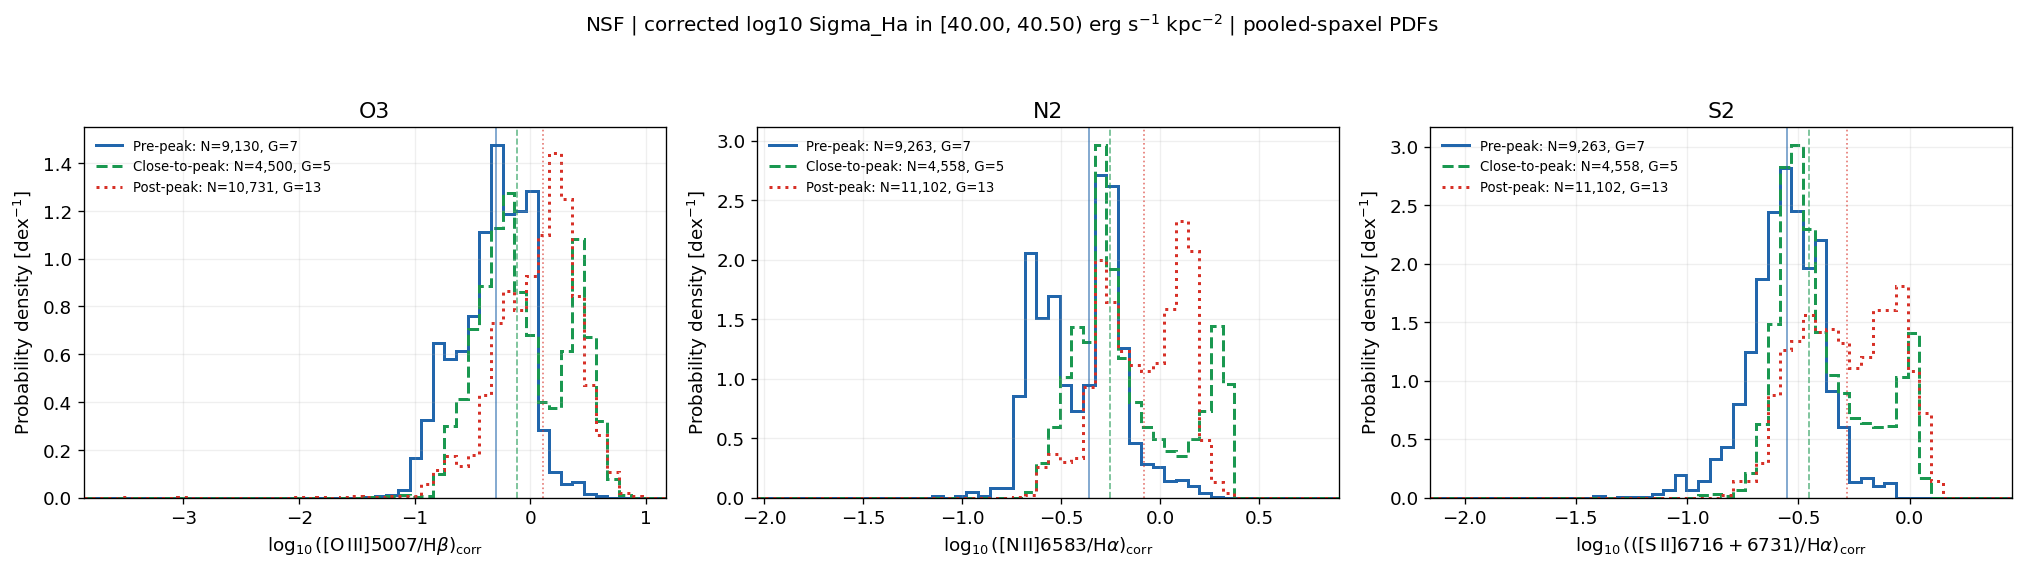

,Sigma_bin,low,high,stage,ratio,N_parent,N_finite,N_unavailable,N_galaxies,N_gas_bins,median_log_Sigma_Ha,median_log_ratio,low_galaxy_support
63,7,40.5,41.0,pre-peak,O3,4437,4357,80,7,3452,40.675138,-0.379743,False
64,7,40.5,41.0,pre-peak,N2,4437,4437,0,7,3484,40.674866,-0.431118,False
65,7,40.5,41.0,pre-peak,S2,4437,4437,0,7,3484,40.674866,-0.636583,False
66,7,40.5,41.0,close-to-peak,O3,677,674,3,5,589,40.692844,-0.653964,False
67,7,40.5,41.0,close-to-peak,N2,677,677,0,5,592,40.692078,-0.492958,False
68,7,40.5,41.0,close-to-peak,S2,677,677,0,5,592,40.692078,-0.602409,False
69,7,40.5,41.0,post-peak,O3,2467,2389,78,12,2214,40.653373,0.172256,False
70,7,40.5,41.0,post-peak,N2,2467,2467,0,12,2273,40.653083,0.048363,False
71,7,40.5,41.0,post-peak,S2,2467,2467,0,12,2273,40.653083,-0.174223,False


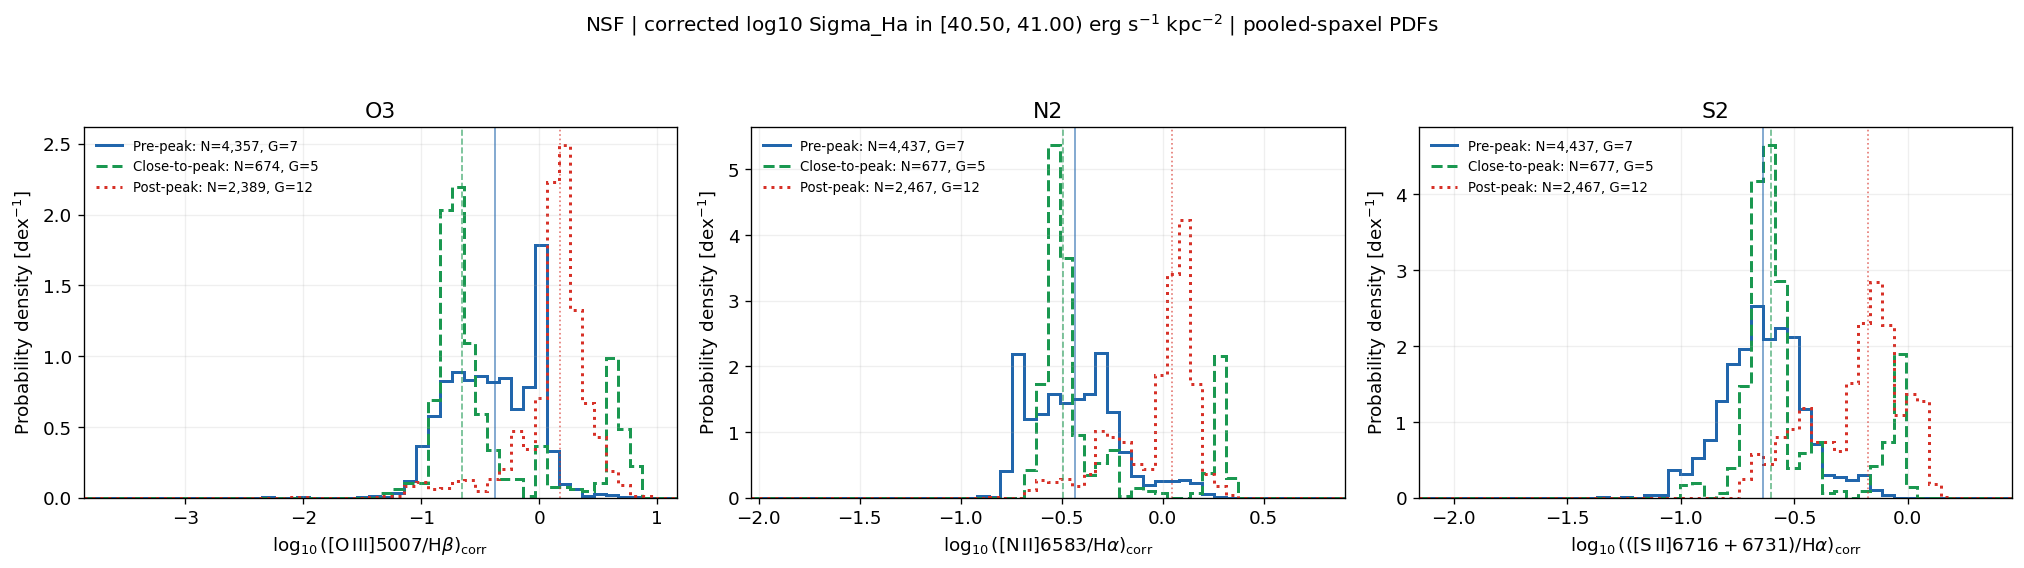

,Sigma_bin,low,high,stage,ratio,N_parent,N_finite,N_unavailable,N_galaxies,N_gas_bins,median_log_Sigma_Ha,median_log_ratio,low_galaxy_support
72,8,41.0,41.5,pre-peak,O3,1357,1332,25,6,1281,41.156132,-0.557409,False
73,8,41.0,41.5,pre-peak,N2,1357,1357,0,6,1299,41.156370,-0.591534,False
74,8,41.0,41.5,pre-peak,S2,1357,1357,0,6,1299,41.156370,-0.696433,False
75,8,41.0,41.5,close-to-peak,O3,331,331,0,4,328,41.169190,-0.734039,False
76,8,41.0,41.5,close-to-peak,N2,331,331,0,4,328,41.169190,-0.539033,False
77,8,41.0,41.5,close-to-peak,S2,331,331,0,4,328,41.169190,-0.685233,False
78,8,41.0,41.5,post-peak,O3,782,769,13,6,760,41.212217,0.049809,False
79,8,41.0,41.5,post-peak,N2,782,782,0,6,773,41.210299,-0.008325,False
80,8,41.0,41.5,post-peak,S2,782,782,0,6,773,41.210299,-0.282779,False


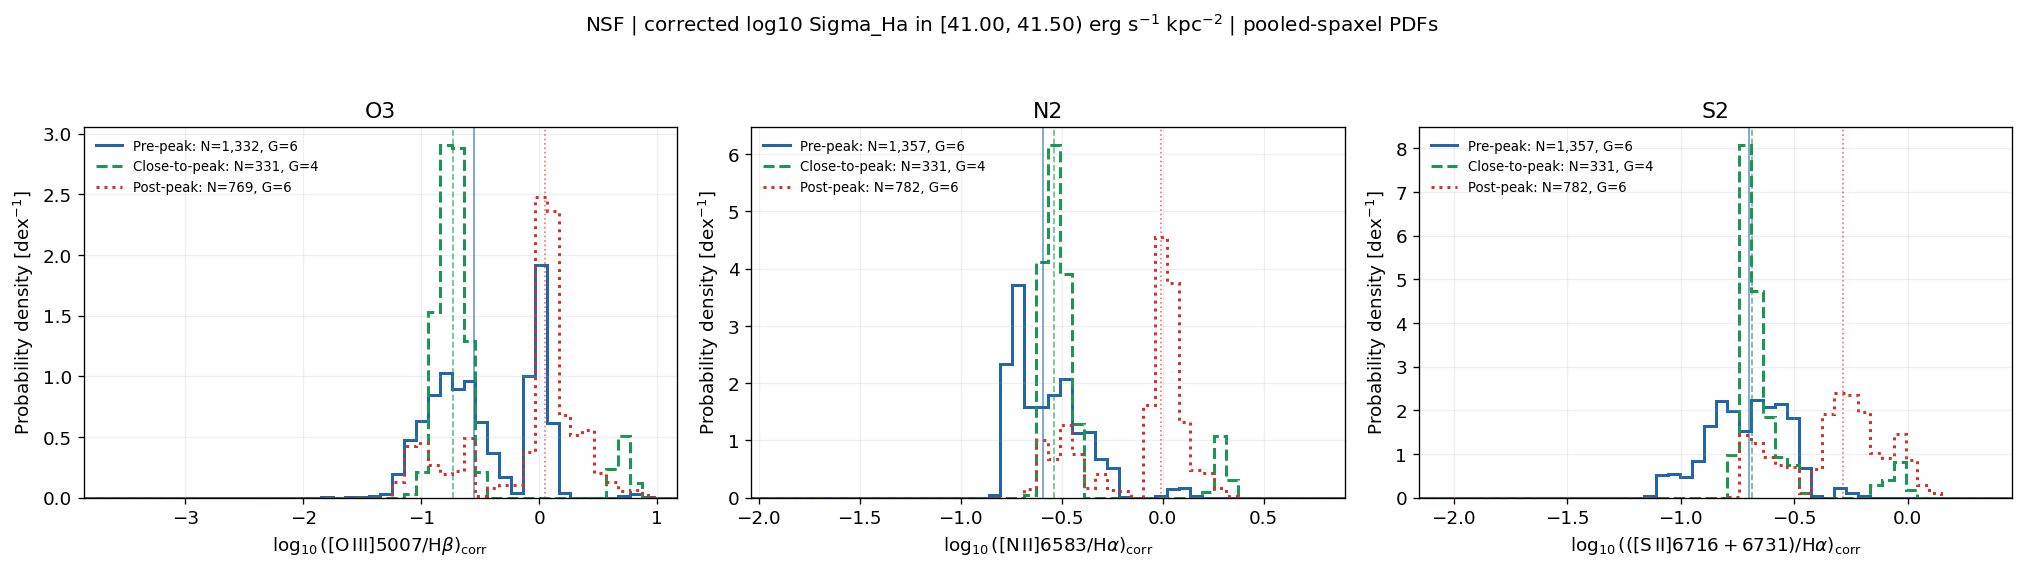

,Sigma_bin,low,high,stage,ratio,N_parent,N_finite,N_unavailable,N_galaxies,N_gas_bins,median_log_Sigma_Ha,median_log_ratio,low_galaxy_support
81,9,41.5,42.0,pre-peak,O3,416,412,4,5,411,41.670681,-0.715579,False
82,9,41.5,42.0,pre-peak,N2,416,416,0,6,415,41.667861,-0.611198,False
83,9,41.5,42.0,pre-peak,S2,416,416,0,6,415,41.667861,-0.751085,False
84,9,41.5,42.0,close-to-peak,O3,15,15,0,1,15,41.631866,-0.923276,True
85,9,41.5,42.0,close-to-peak,N2,15,15,0,1,15,41.631866,-0.447592,True
86,9,41.5,42.0,close-to-peak,S2,15,15,0,1,15,41.631866,-0.773940,True
87,9,41.5,42.0,post-peak,O3,187,185,2,6,185,41.652600,0.011397,False
88,9,41.5,42.0,post-peak,N2,187,187,0,6,187,41.654509,-0.031329,False
89,9,41.5,42.0,post-peak,S2,187,187,0,6,187,41.654509,-0.310175,False


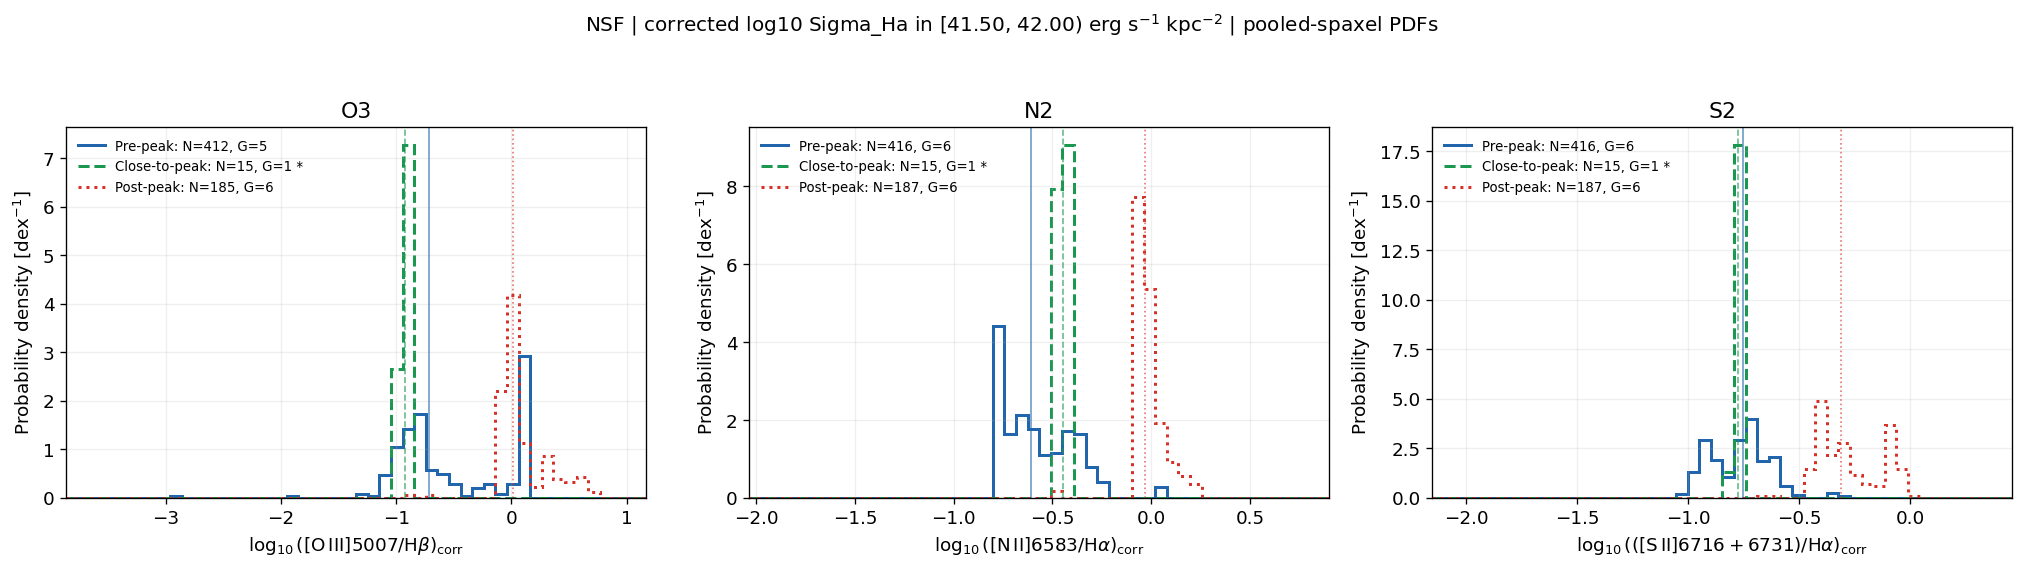

,Sigma_bin,low,high,stage,ratio,N_parent,N_finite,N_unavailable,N_galaxies,N_gas_bins,median_log_Sigma_Ha,median_log_ratio,low_galaxy_support
90,10,42.0,42.5,pre-peak,O3,28,28,0,2,28,42.057925,-0.922241,True
91,10,42.0,42.5,pre-peak,N2,28,28,0,2,28,42.057925,-0.348397,True
92,10,42.0,42.5,pre-peak,S2,28,28,0,2,28,42.057925,-0.687188,True
93,10,42.0,42.5,close-to-peak,O3,0,0,0,0,0,NaN,NaN,True
94,10,42.0,42.5,close-to-peak,N2,0,0,0,0,0,NaN,NaN,True
95,10,42.0,42.5,close-to-peak,S2,0,0,0,0,0,NaN,NaN,True
96,10,42.0,42.5,post-peak,O3,57,56,1,4,56,42.208508,0.051127,False
97,10,42.0,42.5,post-peak,N2,57,57,0,4,57,42.213867,-0.026875,False
98,10,42.0,42.5,post-peak,S2,57,57,0,4,57,42.213867,-0.314140,False


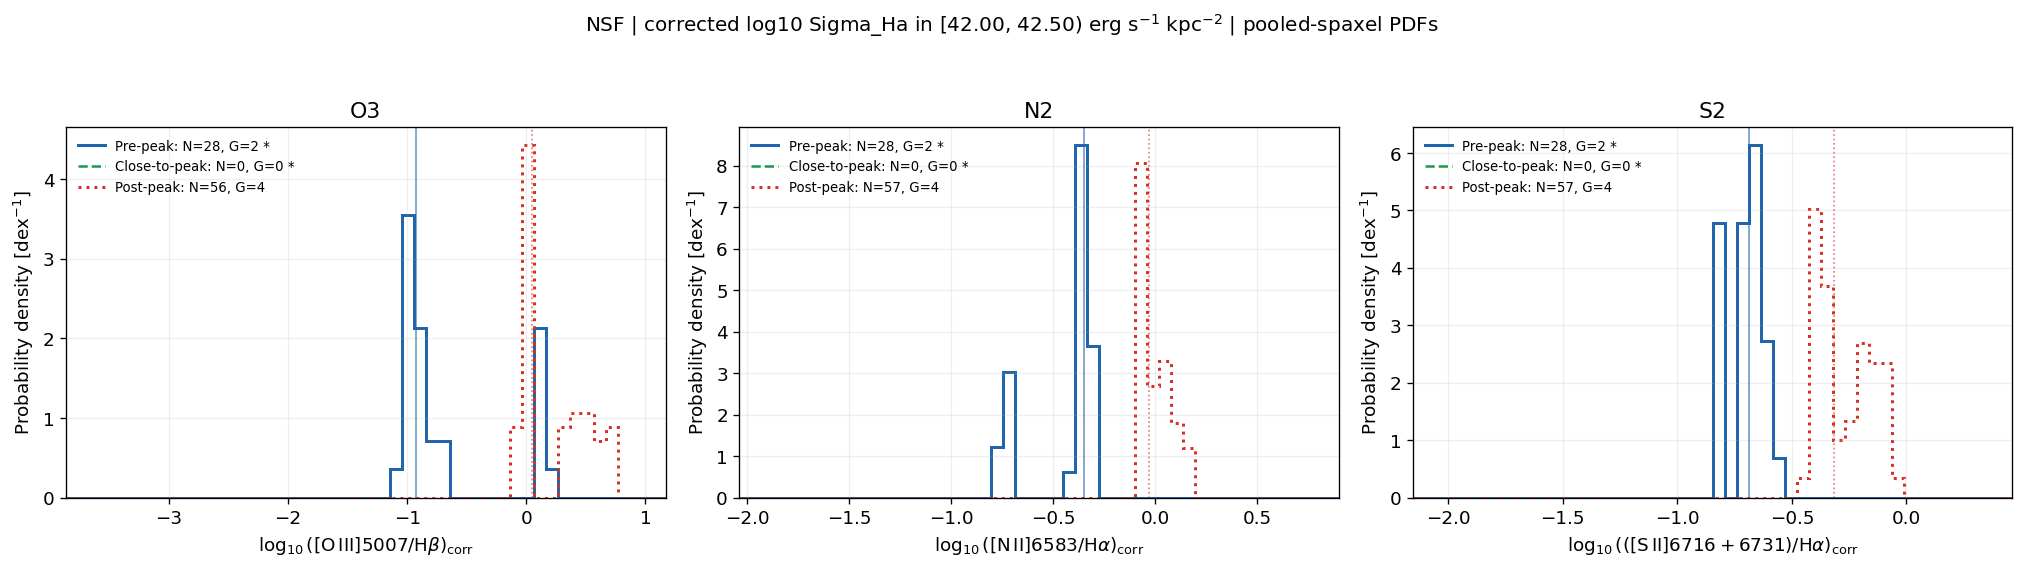

,Sigma_bin,low,high,stage,ratio,N_parent,N_finite,N_unavailable,N_galaxies,N_gas_bins,median_log_Sigma_Ha,median_log_ratio,low_galaxy_support
99,11,42.5,43.0,pre-peak,O3,0,0,0,0,0,NaN,NaN,True
100,11,42.5,43.0,pre-peak,N2,0,0,0,0,0,NaN,NaN,True
101,11,42.5,43.0,pre-peak,S2,0,0,0,0,0,NaN,NaN,True
102,11,42.5,43.0,close-to-peak,O3,0,0,0,0,0,NaN,NaN,True
103,11,42.5,43.0,close-to-peak,N2,0,0,0,0,0,NaN,NaN,True
104,11,42.5,43.0,close-to-peak,S2,0,0,0,0,0,NaN,NaN,True
105,11,42.5,43.0,post-peak,O3,22,22,0,2,22,42.631544,-0.026045,True
106,11,42.5,43.0,post-peak,N2,22,22,0,2,22,42.631544,-0.067802,True
107,11,42.5,43.0,post-peak,S2,22,22,0,2,22,42.631544,-0.403697,True


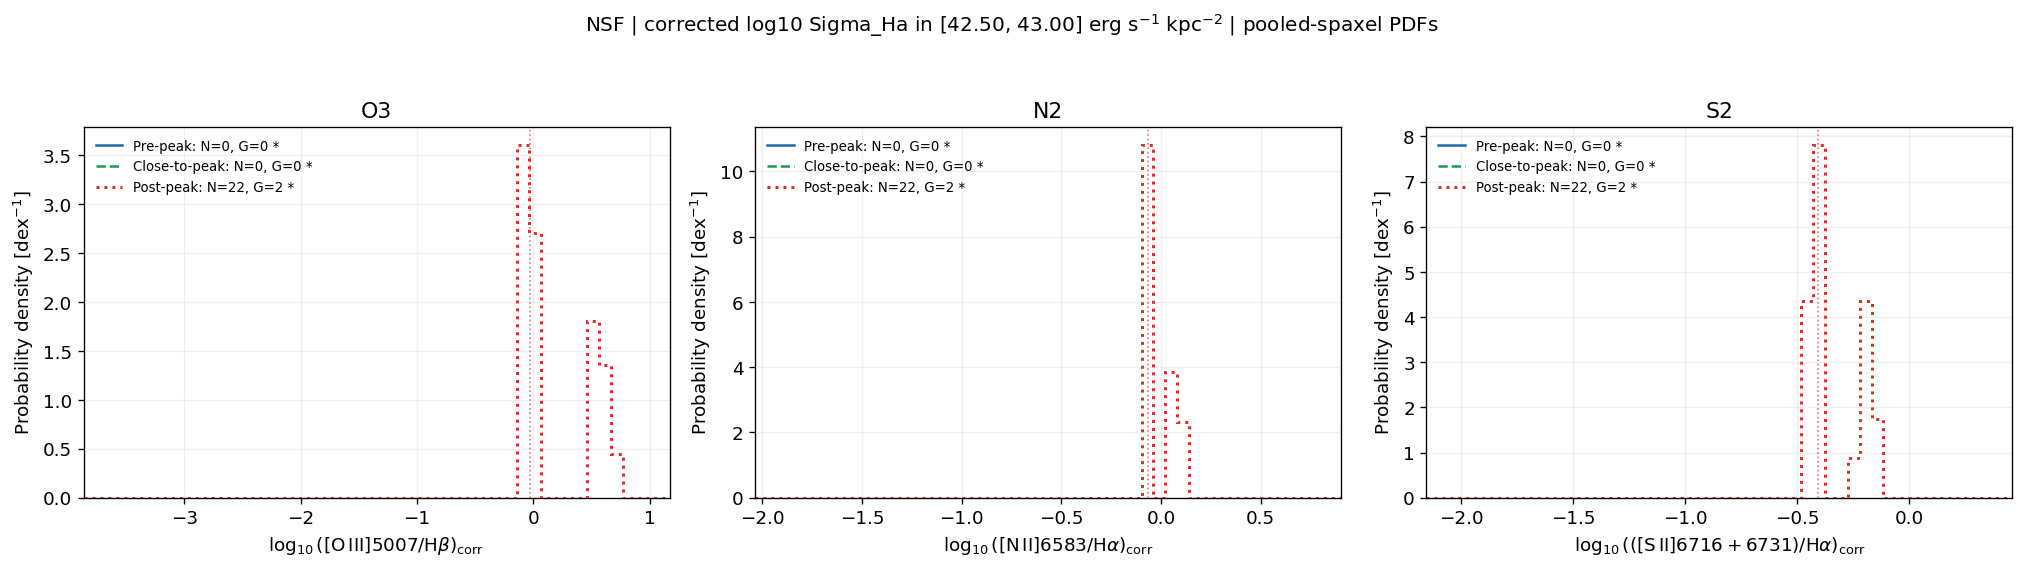

In [6]:
HISTOGRAM_CHECKS = []
def plot_sigma_bin(b):
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    low, high = SIGMA_EDGES[b:b+2]
    right = "]" if b == N_SIGMA_BINS-1 else ")"
    print(f"Sigma_Ha bin {b}: log10 interval [{low:.2f}, {high:.2f}{right}")
    display(BIN_SUPPORT.loc[BIN_SUPPORT.Sigma_bin.eq(b)])
    for ax, ratio in zip(axes, RATIO_ORDER):
        edges = RATIO_EDGES[ratio]
        for stage in STAGE_ORDER:
            sub = NSF_PIXELS.loc[NSF_PIXELS.Sigma_bin.eq(b) & NSF_PIXELS.stage.eq(stage)]
            measured = sub.loc[np.isfinite(sub[ratio])]
            values = measured[ratio].to_numpy()
            ng = measured.GALID.nunique()
            flag = " *" if ng < MIN_GALAXIES_FOR_SUPPORT else ""
            label = f"{STAGE_LABELS[stage]}: N={len(values):,}, G={ng}{flag}"
            if values.size:
                counts, _ = np.histogram(values, bins=edges)
                density = counts / (values.size * np.diff(edges))
                integral = float(np.sum(density * np.diff(edges)))
                assert counts.sum() == values.size
                assert np.isclose(integral, 1.0)
                ax.stairs(density, edges, color=STAGE_COLORS[stage],
                          linestyle=STAGE_STYLES[stage], linewidth=1.8, label=label)
                ax.axvline(np.median(values), color=STAGE_COLORS[stage],
                           linestyle=STAGE_STYLES[stage], linewidth=1, alpha=0.65)
                HISTOGRAM_CHECKS.append((b, stage, ratio, integral))
            else:
                ax.plot([], [], color=STAGE_COLORS[stage], linestyle=STAGE_STYLES[stage], label=label)
                HISTOGRAM_CHECKS.append((b, stage, ratio, np.nan))
        ax.set_xlim(edges[0], edges[-1])
        ax.set_ylim(bottom=0)
        ax.set_xlabel(RATIO_LABELS[ratio])
        ax.set_ylabel("Probability density [dex$^{-1}$]")
        ax.set_title(ratio)
        ax.legend(frameon=False, fontsize=8)
        ax.grid(alpha=0.2)
    fig.suptitle(f"NSF | corrected log10 Sigma_Ha in [{low:.2f}, {high:.2f}{right} "
                 "erg s$^{-1}$ kpc$^{-2}$ | pooled-spaxel PDFs", fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()

for b in range(N_SIGMA_BINS):
    plot_sigma_bin(b)

## Descriptive pre-peak contrasts and galaxy contribution check

Positive `pre_minus_close` or `pre_minus_post` means a higher pooled median
log10 ratio in pre-peak at that Halpha interval. NaN means a missing stage
distribution. Interpret a contrast only with the support and within-bin
Sigma_Ha medians above. `GALAXY_BIN_SUMMARY` exposes individual contributions
and medians; `max_galaxy_pixel_fraction` identifies pooled curves dominated
by one product. This section adds no selection and no significance test.

In [7]:
CONTRASTS = BIN_SUPPORT.pivot(index=["Sigma_bin", "low", "high", "ratio"],
                             columns="stage", values="median_log_ratio").reindex(columns=STAGE_ORDER)
CONTRASTS["pre_minus_close"] = CONTRASTS["pre-peak"] - CONTRASTS["close-to-peak"]
CONTRASTS["pre_minus_post"] = CONTRASTS["pre-peak"] - CONTRASTS["post-peak"]
display(CONTRASTS.reset_index())

galaxy_rows = []
for (b, stage, galid), sub in NSF_PIXELS.loc[NSF_PIXELS.Sigma_bin.ge(0)].groupby(
        ["Sigma_bin", "stage", "GALID"], observed=True):
    for ratio in RATIO_ORDER:
        measured = sub.loc[np.isfinite(sub[ratio])]
        if not len(measured):
            continue
        total = BIN_SUPPORT.loc[BIN_SUPPORT.Sigma_bin.eq(b) & BIN_SUPPORT.stage.eq(stage)
                                & BIN_SUPPORT.ratio.eq(ratio), "N_finite"].iloc[0]
        galaxy_rows.append({"Sigma_bin": b, "stage": stage, "GALID": galid, "ratio": ratio,
            "N_pixels": len(measured), "N_gas_bins": measured.gas_bin_id.nunique(),
            "pixel_fraction": len(measured)/total,
            "median_log_Sigma_Ha": measured.log_Sigma_Ha.median(),
            "median_log_ratio": measured[ratio].median()})
GALAXY_BIN_SUMMARY = pd.DataFrame(galaxy_rows)
display(GALAXY_BIN_SUMMARY)
DOMINANCE = GALAXY_BIN_SUMMARY.groupby(["Sigma_bin", "stage", "ratio"], observed=True).agg(
    max_galaxy_pixel_fraction=("pixel_fraction", "max"),
    N_contributing_galaxies=("GALID", "nunique"))
display(DOMINANCE)

assert len(BIN_SUPPORT) == N_SIGMA_BINS * len(STAGE_ORDER) * len(RATIO_ORDER)
assert (BIN_SUPPORT.N_parent == BIN_SUPPORT.N_finite + BIN_SUPPORT.N_unavailable).all()
assert len(HISTOGRAM_CHECKS) == len(BIN_SUPPORT)
assert all(np.isnan(area) or np.isclose(area, 1.0) for _, _, _, area in HISTOGRAM_CHECKS)
for ratio in RATIO_ORDER:
    expected = np.isfinite(NSF_PIXELS.loc[NSF_PIXELS.Sigma_bin.ge(0), ratio]).sum()
    assert BIN_SUPPORT.loc[BIN_SUPPORT.ratio.eq(ratio), "N_finite"].sum() == expected
assert np.allclose(GALAXY_BIN_SUMMARY.groupby(["Sigma_bin", "stage", "ratio"])["pixel_fraction"].sum(), 1)
print(f"NSF_SIGMA_HA_CONDITIONAL_BPT_VALIDATION_OK: {N_SIGMA_BINS} Halpha bins, "
      f"{N_SIGMA_BINS} figures, {len(HISTOGRAM_CHECKS)} stage/ratio distributions")

NSF_SIGMA_HA_CONDITIONAL_BPT_VALIDATION_OK: 12 Halpha bins, 12 figures, 108 stage/ratio distributions


stage,Sigma_bin,low,high,ratio,pre-peak,close-to-peak,post-peak,pre_minus_close,pre_minus_post
0,0,37.0,37.5,N2,NaN,-0.328545,-0.044889,NaN,NaN
1,0,37.0,37.5,O3,NaN,-0.623166,-0.238887,NaN,NaN
2,0,37.0,37.5,S2,NaN,-0.413421,-0.266038,NaN,NaN
3,1,37.5,38.0,N2,-0.098692,-0.194547,0.012211,0.095855,-0.110903
4,1,37.5,38.0,O3,-0.193471,-0.160813,0.049786,-0.032658,-0.243257
5,1,37.5,38.0,S2,-0.173299,-0.089633,-0.148520,-0.083666,-0.024779
6,2,38.0,38.5,N2,-0.210588,-0.265817,-0.036080,0.055229,-0.174508
7,2,38.0,38.5,O3,-0.248797,-0.178756,0.084666,-0.070041,-0.333463
8,2,38.0,38.5,S2,-0.226455,-0.148523,-0.148833,-0.077931,-0.077621
9,3,38.5,39.0,N2,-0.245587,-0.252894,-0.086812,0.007307,-0.158775


,Sigma_bin,stage,GALID,ratio,N_pixels,N_gas_bins,pixel_fraction,median_log_Sigma_Ha,median_log_ratio
0,0,close-to-peak,NGC4424,O3,117,3,0.497872,37.438966,-0.623166
1,0,close-to-peak,NGC4424,N2,117,3,0.497872,37.438966,-0.316908
2,0,close-to-peak,NGC4424,S2,117,3,0.446565,37.438966,-0.146333
3,0,close-to-peak,NGC4501,O3,85,3,0.361702,37.476225,-0.767804
4,0,close-to-peak,NGC4501,N2,85,3,0.361702,37.476225,-0.562535
...,...,...,...,...,...,...,...,...,...
674,11,post-peak,NGC4293,N2,8,8,0.363636,42.672366,0.056260
675,11,post-peak,NGC4293,S2,8,8,0.363636,42.672366,-0.197474
676,11,post-peak,NGC4419,O3,14,14,0.636364,42.627231,-0.043660
677,11,post-peak,NGC4419,N2,14,14,0.636364,42.627231,-0.076122


max_galaxy_pixel_fraction  N_contributing_galaxies
Sigma_bin stage         ratio                                                    
0         close-to-peak N2                      0.497872                        3
                        O3                      0.497872                        3
                        S2                      0.446565                        3
          post-peak     N2                      0.353142                        8
                        O3                      0.346758                        8
...                                                  ...                      ...
10        pre-peak      O3                      0.750000                        2
                        S2                      0.750000                        2
11        post-peak     N2                      0.636364                        2
                        O3                      0.636364                        2
                        S2                      0.636364                        2

[96 rows x 2 columns]

## Reading this test

A consistent pre-peak shift toward higher ratios at comparable Sigma_Ha would
support a stage-associated excitation difference in the selected NSF population.
The direction must be inspected separately for O3, N2 and S2. An absent or
reversed contrast is also a useful outcome; no direction is imposed by the code.

Halpha control is approximate within a finite-width interval. Repeat with
narrower bins to assess residual Halpha mixing, checking galaxy support and
within-bin Sigma_Ha medians each time. Positive-flux selection is not the same
as a robust forbidden-line detection. Dust correction, shared Halpha denominators
for N2/S2, and Balmer-detection selection can couple these measurements.

These descriptive comparisons do not isolate global sSFR from mass, radius,
metallicity, inclination, or excitation sources, and pre-peak is not a measured
sSFR value here. Galaxy-level inference and measured system sSFR would be needed
to make the proposed sSFR interpretation stronger. Spatial pixels and pixels
sharing a fitted gas bin must not be treated as independent observations.